In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("students.csv")

# Show first 5 rows
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [2]:
# Column names
print(df.columns)

# Dataset info
print(df.info())

# Check missing values
print(df.isnull().sum())

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None
gender                         0
race/ethnicity                 0
parental level o

In [3]:
# Clean column names (replace spaces with underscore)
df.columns = df.columns.str.replace(" ", "_")

# Show updated column names
print(df.columns)

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')


In [4]:
# Add Total score
df["total_score"] = df["math_score"] + df["reading_score"] + df["writing_score"]

# Add Average score
df["average_score"] = df["total_score"] / 3

# Show updated data
print(df.head())

   gender race/ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test_preparation_course  math_score  reading_score  writing_score  \
0                    none          72             72             74   
1               completed          69             90             88   
2                    none          90             95             93   
3                    none          47             57             44   
4                    none          76             78             75   

   total_score  average_score  
0          218      72.666667  
1          247      82.333333  
2          278      92.666667  
3          148      49.3

In [5]:
# Find topper (highest total score)
topper = df.loc[df["total_score"].idxmax()]

print("Topper Details:")
print(topper)

Topper Details:
gender                                    female
race/ethnicity                           group E
parental_level_of_education    bachelor's degree
lunch                                   standard
test_preparation_course                     none
math_score                                   100
reading_score                                100
writing_score                                100
total_score                                  300
average_score                              100.0
Name: 458, dtype: object


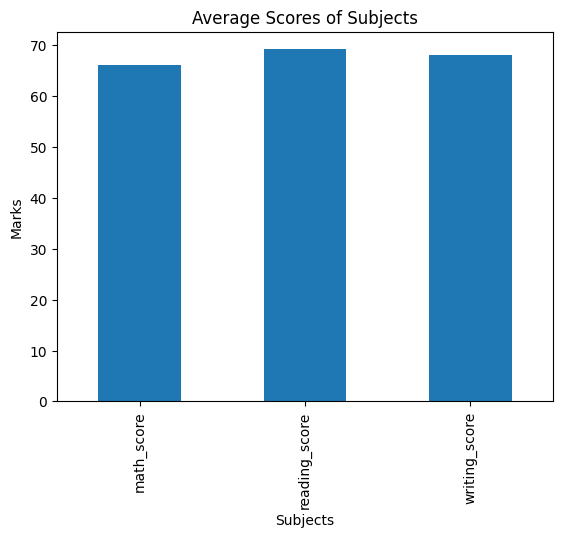

In [6]:
import matplotlib.pyplot as plt

# Average scores of subjects
avg_scores = df[["math_score", "reading_score", "writing_score"]].mean()

# Plot bar chart
avg_scores.plot(kind='bar')

plt.title("Average Scores of Subjects")
plt.xlabel("Subjects")
plt.ylabel("Marks")

plt.show()

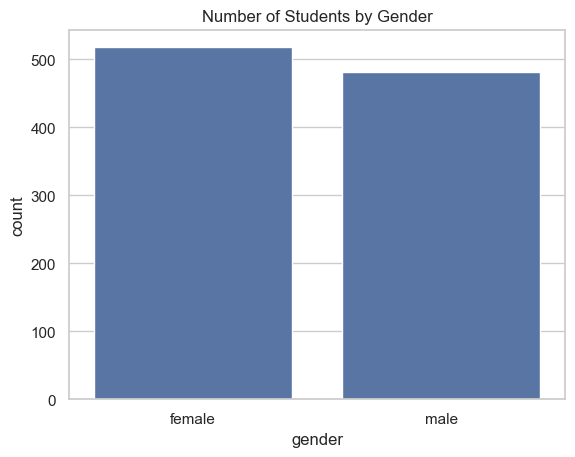

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Style
sns.set(style="whitegrid")

# Count of students by gender
sns.countplot(x="gender", data=df)

plt.title("Number of Students by Gender")
plt.show()

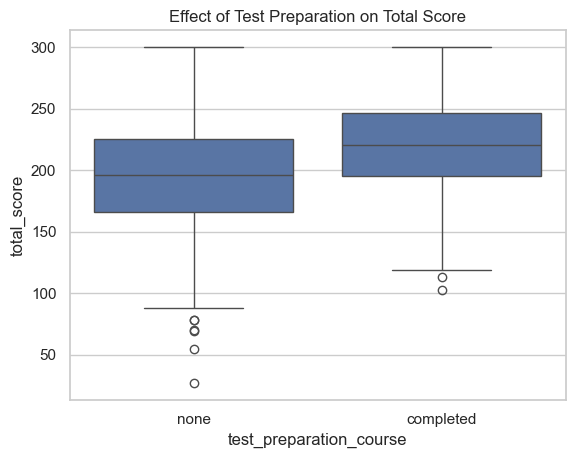

In [8]:
# Compare scores based on test preparation
sns.boxplot(x="test_preparation_course", y="total_score", data=df)

plt.title("Effect of Test Preparation on Total Score")
plt.show()